## Download ALL sectors or chosen ones (Anakin noooo)

In [2]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = "ALL"
flux_column = "pdcsap_flux"

download.download(INPUT, OUTDIR, SECTOR, flux_column=flux_column)

2 targets
Sector: ALL
   1 TIC 396298498: 9 sectors, 137193 pts, baseline 1871.4 d -> TIC396298498_SPOC_PDCSAP.txt
   2 TIC 407514449: 12 sectors, 196990 pts, baseline 1872.2 d -> TIC407514449_SPOC_PDCSAP.txt

Finished


In [ ]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = 42

download.download(INPUT, OUTDIR, SECTOR)

We see it downloaded 5 sectors

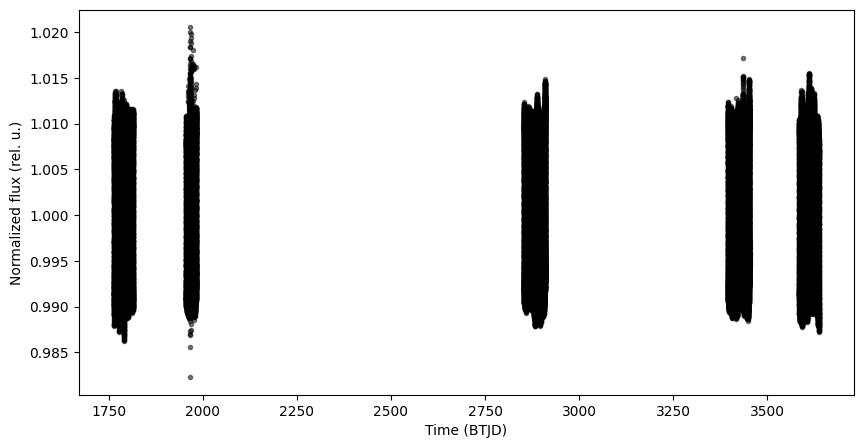

In [11]:
import numpy as np
import matplotlib.pyplot as plt

time, flux, flux_err = np.loadtxt('lightcurves/TIC396298498_SPOC.txt', unpack=True)

plt.subplots(figsize=(10, 5))
plt.plot(time, flux, marker='.', linestyle='none', color='black', alpha=0.5)
plt.xlabel('Time (BTJD)')
plt.ylabel('Normalized flux (rel. u.)')
plt.show()


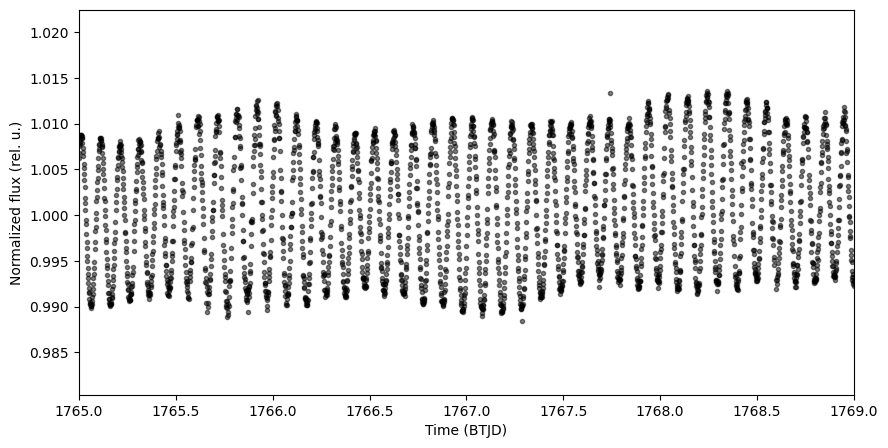

In [13]:
import numpy as np
import matplotlib.pyplot as plt

time, flux, flux_err = np.loadtxt('lightcurves/TIC396298498_SPOC.txt', unpack=True)

plt.subplots(figsize=(10, 5))
plt.plot(time, flux, marker='.', linestyle='none', color='black', alpha=0.5)
plt.xlabel('Time (BTJD)')
plt.ylabel('Normalized flux (rel. u.)')
plt.xlim(1765,1769)
plt.show()

## Extracting frequencies

In [1]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = "ALL"
flux_column = "sap_flux"

download.download(INPUT, OUTDIR, SECTOR, flux_column=flux_column)

2 targets
Sector: ALL
   1 TIC 396298498: 9 sectors, 147909 pts, baseline 1871.4 d -> TIC396298498_SPOC_SAP.txt
   2 TIC 407514449: 12 sectors, 207142 pts, baseline 1872.2 d -> TIC407514449_SPOC_SAP.txt

Finished


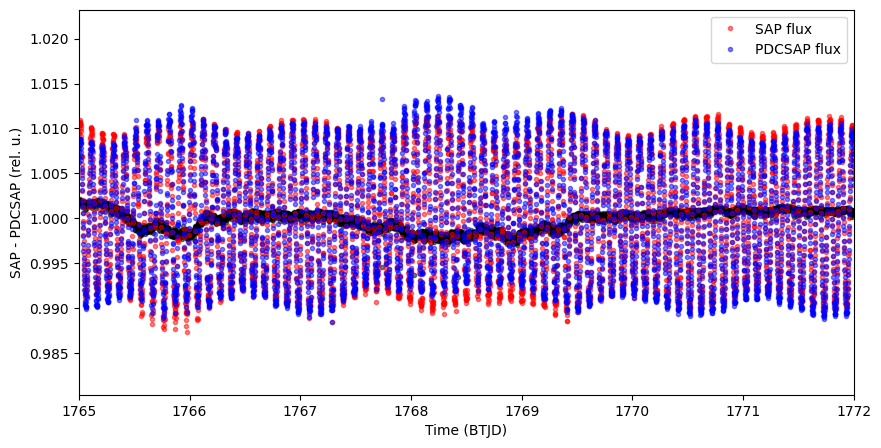

In [12]:
import numpy as np
import matplotlib.pyplot as plt

time1, flux1, flux_err1 = np.loadtxt('lightcurves/TIC396298498_SPOC_SAP.txt', unpack=True)
time2, flux2, flux_err2 = np.loadtxt('lightcurves/TIC396298498_SPOC_PDCSAP.txt', unpack=True)

# Keep only time points present in BOTH light curves
time_common, i1, i2 = np.intersect1d(time1, time2, return_indices=True)
flux1_common = flux1[i1]
flux2_common = flux2[i2]

plt.subplots(figsize=(10, 5))

plt.plot(time_common,flux1_common - flux2_common +1,
         marker='.',
         linestyle='none',
         color='black',alpha=0.5)

plt.plot(time1, flux1, marker='.', linestyle='none', color='red', alpha=0.5, label='SAP flux')
plt.plot(time2, flux2, marker='.', linestyle='none', color='blue', alpha=0.5, label='PDCSAP flux')


plt.xlabel('Time (BTJD)')
plt.ylabel('SAP - PDCSAP (rel. u.)')
plt.xlim(1765,1772)
plt.legend()


plt.show()

In [5]:
import importlib
import prewhitten

importlib.reload(prewhitten)

prewhitten.prewhitten(
    INPUT_DIR="lightcurves/TIC396298498_SPOC_SAP.txt",
    OUTDIR="periodograms",
    SNR_LIMIT=4.0,
    MAX_FREQS=50,
    MAX_FREQUENCY=80
)

0 light curves

Finished


In [6]:
import os
import glob

FILE = "lightcurves/TIC396298498_SPOC_PDCSAP.txt"

print("Current directory:", os.getcwd())
print("File exists:", os.path.exists(FILE))
print("Files in lightcurves:")
print(glob.glob("lightcurves/*.txt")[:20])

Current directory: /Users/michalzummer/Documents/DeltaSct/TESS/TEST11/TESTgit
File exists: True
Files in lightcurves:
['lightcurves/TIC396298498_SPOC_PDCSAP.txt', 'lightcurves/TIC407514449_SPOC_PDCSAP.txt', 'lightcurves/TIC407514449_SPOC_SAP.txt', 'lightcurves/TIC396298498_SPOC.txt', 'lightcurves/TIC407514449_SPOC.txt', 'lightcurves/TIC396298498_SPOC_SAP.txt']


In [7]:
import os

print(os.path.exists(
    "periodograms/TIC396298498_SPOC_PDCSAP_frequencies.txt"
))

False


In [1]:
import importlib
import prewhitten

importlib.reload(prewhitten)

prewhitten.prewhitten(
    INPUT_DIR="lightcurves/TIC396298498_SPOC_PDCSAP.txt",
    OUTDIR="periodograms"
)

0 light curves

Finished
